In [1]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 22.3 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install anndata==0.8.0

In [3]:
!pip install -U kaleido

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.6 MB/s eta 0:00:0000:0100:01


In [84]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

In [4]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [10]:
df_plt = pd.DataFrame(columns = ['celltype_org','celltype_ref','mapping','num_cells'])

In [11]:
a = 0

In [88]:
sam_mg = SAM()
sam_mg.load_data('Subclustering/MNPO/SAM_Allen_Institute_MNPO.h5ad')

In [89]:
sam_mo = SAM()
sam_mo.load_data('Subclustering/MNPO/SAM_MO_soupx_plus5_cleaned_MNPO_08182025.h5ad')

In [90]:
sam_cj = SAM()
sam_cj.load_data('Subclustering/MNPO/SAM_CJ_joined_v2_cleaned_08182025_MNPO.h5ad')

In [91]:
sam_ac = SAM()
sam_ac.load_data('Subclustering/MNPO/SAM_AC_ncbi_soupx_cleaned_08182025_MNPO.h5ad')

In [92]:
sam_ri = SAM()
sam_ri.load_data('Subclustering/MNPO/RI_116_AVPV-MEPO-SFO_Tbr1_Glut_ss_subclass_crossed_nn_04282026.h5ad')

In [39]:
sm = load_samap('Active_SAMap_Joined/sm_hyporirv_mnpo_05202026.pkl')

In [ ]:
sm.sams['ri'].adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters',
       'subclass_id_label_mapping', 'subclass_id_label_lc',
       'subclass_id_label_mapping_nounlabeled', 'subclass_id_label_crossed',
       'subclass_id_label_crossed_nn', 'subclass_lc', 'ss_subclass',
       'ss_subclass_nn', 'ss_subclass_nounlabeled_nn',
       'ss_subclass_crossed_nn', 'ss_subclass_nounlabeled_nn_agrp',
       'eq_supertype_cl'],
      dtype='object')

In [ ]:
reso = [.1,.2,.33,.4,.5,.6,.7,.8,.9,1]
for i in reso:
    sm.sams['rv'].clustering(param = i)
    print(sm.sams['rv'].adata.obs['leiden_clusters'].nunique())

3
4
5
5
5
5
5
6
6
7


In [ ]:
sm.sams['ri'].clustering(param = .33)
sm.sams['rv'].clustering(param = .33)

sm.sams['ri'].adata.obs['eq_supertype_cl'] = sm.sams['ri'].adata.obs['leiden_clusters']
sm.sams['rv'].adata.obs['eq_supertype_cl'] = sm.sams['rv'].adata.obs['leiden_clusters']

In [ ]:
mapping = {0:'RI_0',5:'RI_0',6:'RI_6',7:'RI_6'}
fin = []
for item in sm.sams['ri'].adata.obs['eq_supertype_cl']:
    if item in mapping:
        fin.append(mapping[item])
    else:
        fin.append('RI_' + str(item))
sm.sams['ri'].adata.obs['eq_supertype_cl'] = fin

In [ ]:
sm.sams['ri'].adata.obs['eq_supertype_cl']

AACAACCGTCGCTGCA Run 18 sample 2     RI_2
AACCAACGTCACTCTC Run 18 sample 2     RI_1
AACCAACTCATACAGC Run 18 sample 2     RI_0
AACCTGAAGCTACTGT Run 18 sample 2     RI_0
AAGACAAGTACCAGAG Run 18 sample 2     RI_3
                                     ... 
TCGTAGAAGGCCTTGC Run 18 sample 10    RI_3
TCGTAGATCACTCTTA Run 18 sample 10    RI_2
TGAGACTAGGTAGCAC Run 18 sample 10    RI_1
TGCGGCAAGTTGCATC Run 18 sample 10    RI_1
TGGGAAGTCGCGGACT Run 18 sample 10    RI_6
Name: eq_supertype_cl, Length: 483, dtype: object

In [ ]:
mapping = {3:'RV_3',4:'RV_3'}
fin = []
for item in sm.sams['rv'].adata.obs['eq_supertype_cl']:
    if item in mapping:
        fin.append(mapping[item])
    else:
        fin.append('RV_' + str(item))
sm.sams['rv'].adata.obs['eq_supertype_cl'] = fin

In [ ]:
sm.sams['ac'].adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,n_counts,n_genes,key,leiden_clusters,region_label,neurotransmitter,nCount_SCT,...,ss_subclass_nounlabeled,ss_class,ss_subclass_nounlabeled_astro,ss_subclass_v2,ss_subclass_v2_nounlabeled,ss_subclass_v3_nounlabeled,ss_subclass_nounlabeled_nmm,eq_clusters,eq_supertype,eq_supertype_cl
CTCAATTCAGTGTGCC,AC,1961.0,1262,1961.0,1262,Run12_sample2,5,MnPO,Glut,1891.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,Foxp2 + Ebf1 + Reln,AC_3
GCCAACGGTATCCTCC,AC,4543.0,2213,4543.0,2213,Run12_sample2,8,MnPO,Glut,2255.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,Foxp2 + Ebf1 + Reln,AC_3
GGTGTTAAGGTGCCAA,AC,2028.0,1256,2028.0,1256,Run12_sample2,4,MnPO,Glut,1928.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,Foxp2 + Ebf1 + Reln,AC_3
GTAGCTAAGAAAGCGA,AC,2008.0,1240,2008.0,1240,Run12_sample2,5,MnPO,Glut,1924.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,Foxp2 + Ebf1 + Reln,AC_3
GTGTGGCCAGATACTC,AC,1419.0,917,1419.0,917,Run12_sample2,9,MnPO,Glut,1493.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,4,Foxp2 + Ebf1 + Reln,AC_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGCGGCACAGTCAACT,AC,8938.0,3545,8938.0,3545,Run17_sample4,4,Unknown,Glut,4559.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,4,Foxp2 + Ebf1 + Reln,AC_3
TTAGGGTGTCGACGCT,AC,5297.0,2357,5297.0,2357,Run17_sample4,8,MnPO,Glut,4557.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,Foxp2 + Ebf1 + Reln,AC_3
TTCGCTGAGGCAGGGA,AC,1526.0,936,1526.0,936,Run17_sample4,8,MnPO,Glut,3299.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,Foxp2 + Ebf1 + Reln,AC_3
TTCTTCCAGAGGGTAA,AC,2373.0,1208,2373.0,1208,Run17_sample4,5,MnPO,Glut,3451.0,...,116 AVPV-MEPO-SFO Tbr1 Glut,13 CNU-HYa Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,Foxp2 + Ebf1 + Reln,AC_3


In [93]:
sam_mo.adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,n_counts,n_genes,key,subclass_id_label_mapping,subclass_id_label_lc,leiden_clusters,subclass_id_label_mapping_nounlabeled,...,eq_subclass_nounlabeled,NN,ss_subclass,ss_subclass_nounlabeled,eq_clusters,eq_supertype,eq_supertype_cl,test,eq_supertype_cl_v2,eq_clusters_v2
AAAGTCCCAGTCCCGA,MO,11216.0,3798,11216.0,3798,Run12_sample1,116 AVPV-MEPO-SFO Tbr1 Glut,280,4,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,4,4,MO_3,MM_Foxp2_1,MM_Foxp2_1,4
AAATGGATCATTACCT,MO,4868.0,2696,4868.0,2696,Run12_sample1,116 AVPV-MEPO-SFO Tbr1 Glut,66,2,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,2,Etv1 + Reln + Ebf1,MO_1,MM_Thirst,MM_Thirst,2
AACACACGTATCGTTG,MO,5071.0,2776,5071.0,2776,Run12_sample1,116 AVPV-MEPO-SFO Tbr1 Glut,28,3,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,3,3,MO_2,MM_Warmth,MM_Warmth,3
AAGTGAAAGATACTGA,MO,4438.0,2267,4438.0,2267,Run12_sample1,116 AVPV-MEPO-SFO Tbr1 Glut,357,2,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,2,Etv1 + Reln + Ebf1,MO_1,MM_Thirst,MM_Thirst,2
AATAGAGGTGACTGTT,MO,4736.0,2638,4736.0,2638,Run12_sample1,116 AVPV-MEPO-SFO Tbr1 Glut,28,3,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,3,3,MO_2,MM_Warmth,MM_Warmth,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTGTTCAAGTGGGT,MO,4666.0,2344,4666.0,2344,Run12_sample12,116 AVPV-MEPO-SFO Tbr1 Glut,55,1,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,1,Opn5,MO_2,MM_Warmth,MM_Warmth,1
TTTACGTCATGGCGCT,MO,4529.0,2401,4529.0,2401,Run12_sample12,116 AVPV-MEPO-SFO Tbr1 Glut,6,0,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,0,MO_4,MM_Brs3,MM_Brs3,0
TTTAGTCTCTTTACAC,MO,7124.0,2941,7124.0,2941,Run12_sample12,116 AVPV-MEPO-SFO Tbr1 Glut,6,0,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,0,0,MO_4,MM_Brs3,MM_Brs3,0
TTTATGCCACAACGCC,MO,4302.0,2339,4302.0,2339,Run12_sample12,116 AVPV-MEPO-SFO Tbr1 Glut,280,4,116 AVPV-MEPO-SFO Tbr1 Glut,...,116 AVPV-MEPO-SFO Tbr1 Glut,Neuron,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,4,4,MO_3,MM_Foxp2_1,MM_Foxp2_1,4


In [32]:
sm.sams['ac'].adata.obs['eq_supertype_cl'] = sam_ac.adata.obs['eq_supertype_cl']

In [7]:
sm.sams['cj'].adata.obs['eq_supertype'].value_counts(normalize=True).to_dict()figure5

{'Nos1': 0.4251781472684085,
 'Rxfp1': 0.2589073634204275,
 'Foxp2': 0.16389548693586697,
 'Etv1 + Reln + Ebf1': 0.15201900237529692}

In [94]:
sm.sams['mo'].adata.obs['eq_supertype_cl_v2'] = sam_mo.adata.obs['eq_supertype_cl_v2']
sm.sams['cj'].adata.obs['eq_supertype_cl_v2'] = sam_cj.adata.obs['eq_supertype_cl_v2']
sm.sams['ac'].adata.obs['eq_supertype_cl_v2'] = sam_ac.adata.obs['eq_supertype_cl_v2']
sm.sams['ri'].adata.obs['eq_supertype_cl_v2'] = sam_ri.adata.obs['eq_supertype_cl_v2']

In [74]:
sm.sams['mg'].adata.obs['test'] = sm.sams['mg'].adata.obs['eq_supertype_cl_v2']

In [106]:
orgs = ['mg','mo','cj','ac','ri']
pairs = [list(pair) for pair in itertools.combinations(orgs, 2)]
level = 'eq_supertype_cl_v2'
for org_one, org_two in pairs:
    print(org_one, org_two)
    df_plt = pd.DataFrame(columns = ['celltype_org','celltype_ref','mapping','num_cells'])
    a = 0
    keys = {org_one:level,org_two:level}
    D,MappingTable = get_mapping_scores(sm,keys)

    lim_MappingTable = MappingTable.filter(like=org_one + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]
    lim_MappingTable.to_csv('Subclustering/MNPO/' + org_one + '_' + org_two + '_mapping_07082026_clusters.csv')

mg mo
mg cj
mg ac
mg ri
mo cj
mo ac
mo ri
cj ac
cj ri
ac ri


In [22]:
sm.sams['mg'].adata.obs['eq_supertype'].unique()

['Nos1 + Foxp2', 'Rxfp1 + Agtr1a', 'Brs3', '0520 AVPV-MEPO-SFO Tbr1 Glut_2', 'Ebf1']
Categories (5, object): ['0520 AVPV-MEPO-SFO Tbr1 Glut_2', 'Brs3', 'Ebf1', 'Nos1 + Foxp2', 'Rxfp1 + Agtr1a']

In [14]:
org_one = 'mg'
org_two = 'cj'
level = 'eq_supertype'
keys = {org_one:level,org_two:level}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like=org_one)
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two)]

sankey_plot(MappingTable, align_thr=0.2, bgcolor = 'white')

:Sankey   [source,target]   (Value)

In [159]:
#all dfs load
ct = 'MNPO'
MG_MO = pd.read_csv('Subclustering/' + ct + '/mg_mo_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
MG_CJ = pd.read_csv('Subclustering/' + ct + '/mg_cj_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
MG_AC = pd.read_csv('Subclustering/' + ct + '/mg_ac_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
MG_RI = pd.read_csv('Subclustering/' + ct + '/mg_ri_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
#MG_RV = pd.read_csv('Subclustering/' + ct + '/mg_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0')
MO_MG = pd.read_csv('Subclustering/' + ct + '/mg_mo_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
MO_CJ = pd.read_csv('Subclustering/' + ct + '/mo_cj_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
MO_AC = pd.read_csv('Subclustering/' + ct + '/mo_ac_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
MO_RI = pd.read_csv('Subclustering/' + ct + '/mo_ri_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
#MO_RV = pd.read_csv('Subclustering/' + ct + '/mo_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0')
CJ_MG = pd.read_csv('Subclustering/' + ct + '/mg_cj_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
CJ_MO = pd.read_csv('Subclustering/' + ct + '/mo_cj_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
CJ_AC = pd.read_csv('Subclustering/' + ct + '/cj_ac_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
CJ_RI = pd.read_csv('Subclustering/' + ct + '/cj_ri_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
#CJ_RV = pd.read_csv('Subclustering/' + ct + '/cj_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0')
AC_MG = pd.read_csv('Subclustering/' + ct + '/mg_ac_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
AC_MO = pd.read_csv('Subclustering/' + ct + '/mo_ac_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
AC_CJ = pd.read_csv('Subclustering/' + ct + '/cj_ac_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
AC_RI = pd.read_csv('Subclustering/' + ct + '/ac_ri_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0')
#AC_RV = pd.read_csv('Subclustering/' + ct + '/ac_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0')
RI_MG = pd.read_csv('Subclustering/' + ct + '/mg_ri_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
RI_MO = pd.read_csv('Subclustering/' + ct + '/mo_ri_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
RI_CJ = pd.read_csv('Subclustering/' + ct + '/cj_ri_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
RI_AC = pd.read_csv('Subclustering/' + ct + '/ac_ri_mapping_07082026_clusters.csv', index_col = 'Unnamed: 0').T
#RI_RV = pd.read_csv('Subclustering/' + ct + '/ri_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0')
#RV_MG = pd.read_csv('Subclustering/' + ct + '/mg_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0').T
#RV_MO = pd.read_csv('Subclustering/' + ct + '/mo_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0').T
#RV_CJ = pd.read_csv('Subclustering/' + ct + '/cj_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0').T
#RV_AC = pd.read_csv('Subclustering/' + ct + '/ac_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0').T
#RV_RI = pd.read_csv('Subclustering/' + ct + '/ri_rv_mapping_' + ct + '_clusters.csv', index_col = 'Unnamed: 0').T

In [160]:
MG_MG = pd.DataFrame(data = np.eye(len(MG_CJ.columns)),index = MG_CJ.columns, columns = MG_CJ.columns)
MO_MO = pd.DataFrame(data = np.eye(len(MO_MG.columns)),index = MO_MG.columns, columns = MO_MG.columns)
CJ_CJ = pd.DataFrame(data = np.eye(len(CJ_MG.columns)),index = CJ_MG.columns, columns = CJ_MG.columns)
AC_AC = pd.DataFrame(data = np.eye(len(AC_MG.columns)),index = AC_MG.columns, columns = AC_MG.columns)
RI_RI = pd.DataFrame(data = np.eye(len(RI_MG.columns)),index = RI_MG.columns, columns = RI_MG.columns)
#RV_RV = pd.DataFrame(data = np.eye(len(RV_MG.columns)),index = RV_MG.columns, columns = RV_MG.columns)

In [161]:
MG = pd.concat([MG_MG,MG_MO,MG_CJ,MG_AC,MG_RI])
MO = pd.concat([MO_MG,MO_MO,MO_CJ,MO_AC,MO_RI])
CJ = pd.concat([CJ_MG,CJ_MO,CJ_CJ,CJ_AC,CJ_RI])
AC = pd.concat([AC_MG,AC_MO,AC_CJ,AC_AC,AC_RI])
RI = pd.concat([RI_MG,RI_MO,RI_CJ,RI_AC,RI_RI])
#RV = pd.concat([RV_MG,RV_MO,RV_CJ,RV_AC,RV_RI,RV_RV])

In [162]:
pvh_mapping = pd.concat([MG,MO,CJ,AC,RI], axis =1)

<AxesSubplot:>

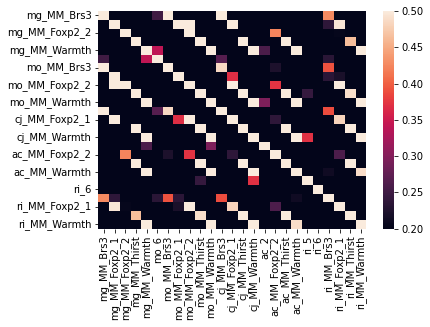

In [163]:
sns.heatmap(pvh_mapping, vmin = .2, vmax = .5)

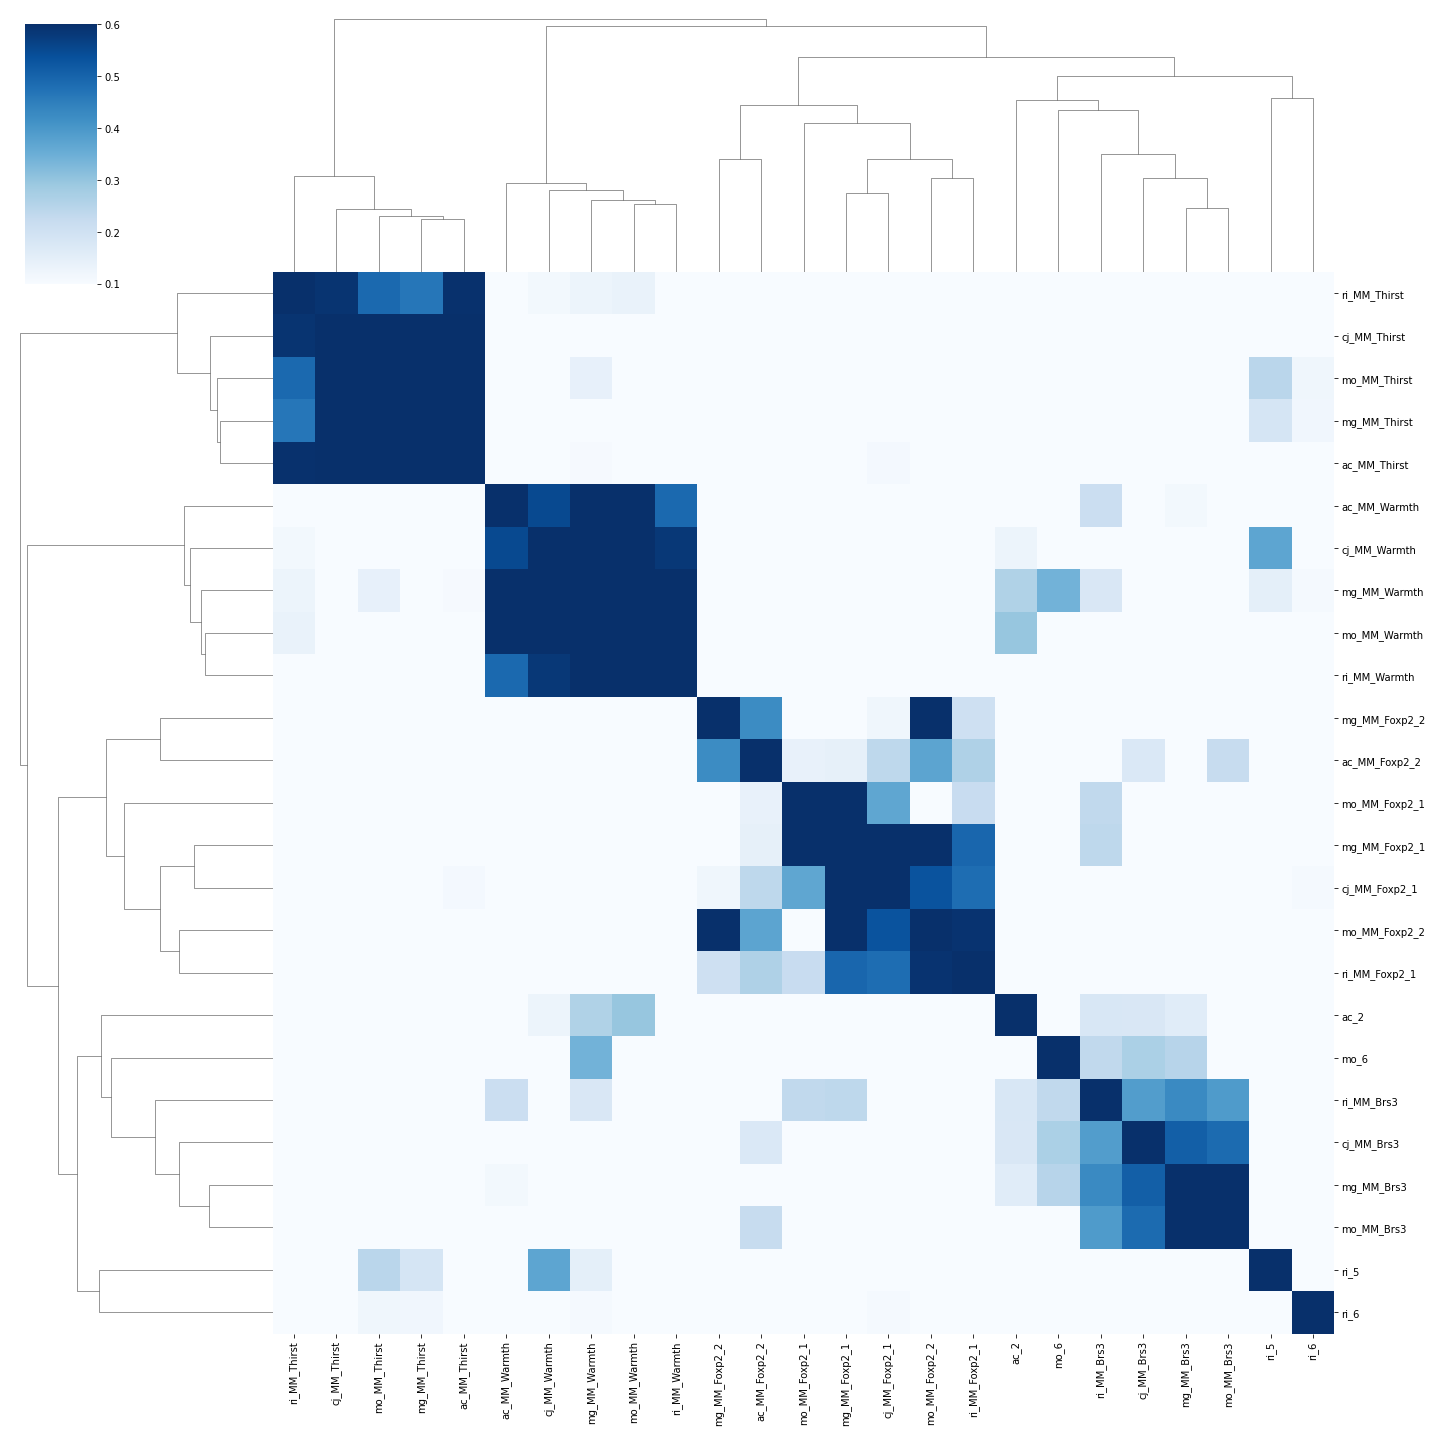

In [164]:
g =sns.clustermap(pvh_mapping, vmax = .6, vmin = .1,cmap = 'Blues',figsize=(20,20))
#plt.savefig('MNPO_mapping_hypothalamus_04102026.svg')

In [165]:
reorder_row = g.dendrogram_row.reordered_ind
reorder_col = g.dendrogram_col.reordered_ind

In [166]:
pvh_mapping.index[reorder_row]

Index(['ri_MM_Thirst', 'cj_MM_Thirst', 'mo_MM_Thirst', 'mg_MM_Thirst',
       'ac_MM_Thirst', 'ac_MM_Warmth', 'cj_MM_Warmth', 'mg_MM_Warmth',
       'mo_MM_Warmth', 'ri_MM_Warmth', 'mg_MM_Foxp2_2', 'ac_MM_Foxp2_2',
       'mo_MM_Foxp2_1', 'mg_MM_Foxp2_1', 'cj_MM_Foxp2_1', 'mo_MM_Foxp2_2',
       'ri_MM_Foxp2_1', 'ac_2', 'mo_6', 'ri_MM_Brs3', 'cj_MM_Brs3',
       'mg_MM_Brs3', 'mo_MM_Brs3', 'ri_5', 'ri_6'],
      dtype='object')

In [167]:
reorder = ['mg_MM_Thirst','mo_MM_Thirst','cj_MM_Thirst','ac_MM_Thirst','ri_MM_Thirst',
          'mg_MM_Warmth', 'mg_MM_Warmth','cj_MM_Warmth','ac_MM_Warmth', 'ri_MM_Warmth',
          'mg_MM_Foxp2_1','mo_MM_Foxp2_1','cj_MM_Foxp2_1','ri_MM_Foxp2_1','mg_MM_Foxp2_2','mo_MM_Foxp2_2','ac_MM_Foxp2_2',
          'mg_MM_Brs3','mo_MM_Brs3','cj_MM_Brs3','ri_MM_Brs3','mo_6','ac_2','ri_5','ri_6']

In [168]:
pvh_mapping_ord = pvh_mapping.loc[reorder,:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,reorder]

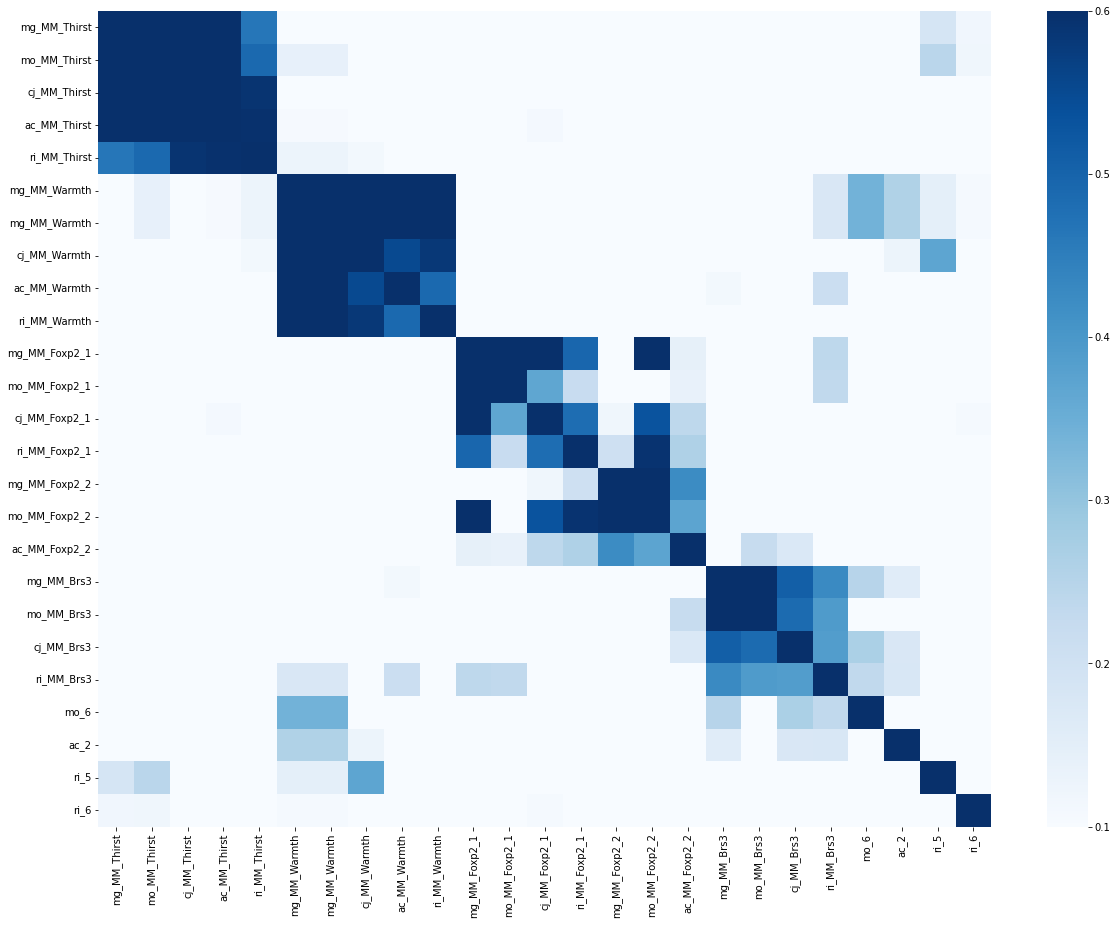

In [169]:
plt.figure(figsize = (20,15))
sns.heatmap(pvh_mapping_ord, vmax = .6, vmin = .1,cmap = 'Blues')
plt.savefig('Figures/Figures_07072026/MNPO_boxplot_hypothalamusri_07072026.svg')
plt.savefig('Figures/Figures_07072026/MNPO_boxplot_hypothalamusri_07072026.pdf')

In [170]:
reorder = ['mg_MM_Thirst','mo_MM_Thirst','cj_MM_Thirst','ac_MM_Thirst','ri_MM_Thirst',
          'mg_MM_Warmth', 'mo_MM_Warmth','cj_MM_Warmth','ac_MM_Warmth', 'ri_MM_Warmth',
          'mg_MM_Foxp2_1','mo_MM_Foxp2_1','cj_MM_Foxp2_1','ri_MM_Foxp2_1','mg_MM_Foxp2_2','mo_MM_Foxp2_2','ac_MM_Foxp2_2',
          'mg_MM_Brs3','mo_MM_Brs3','cj_MM_Brs3','ri_MM_Brs3']

In [171]:
pvh_mapping_ord = pvh_mapping.loc[reorder,:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,reorder]

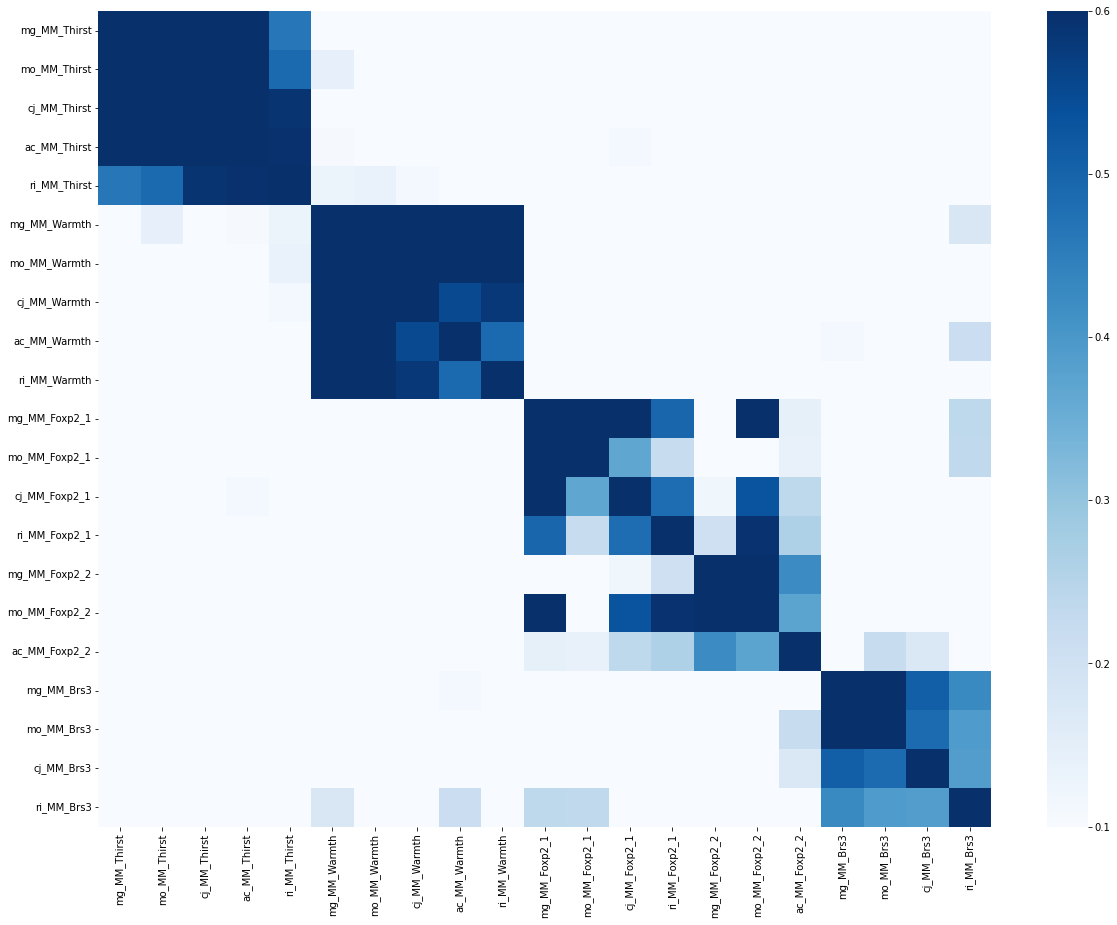

In [172]:
plt.figure(figsize = (20,15))
sns.heatmap(pvh_mapping_ord, vmax = .6, vmin = .1,cmap = 'Blues')
plt.savefig('Figures/Figures_07072026/MNPO_boxplot_hypothalamusri_cl_07072026.svg')
plt.savefig('Figures/Figures_07072026/MNPO_boxplot_hypothalamusri_cl_07072026.pdf')

In [139]:
sam_ri.adata.obs['eq_clusters_v2'] = sam_ac.adata.obs['eq_clusters']

In [148]:
sam_ri.adata.obs['eq_clusters_v2'].unique()

[2, 0, 1, 3, 4, 5, 6]
Categories (7, int64): [0, 1, 2, 3, 4, 5, 6]

In [149]:
sam_ri.clustering(param =0.25)

In [150]:
sam_ri.adata.obs['leiden_clusters'].unique()

[2, 0, 1, 3, 4, 5, 6]
Categories (7, int64): [0, 1, 2, 3, 4, 5, 6]

In [152]:
sam_ri.adata.obs['eq_clusters_v2'].equals(sam_ri.adata.obs['leiden_clusters'])

True

In [153]:
sam_mg.save_anndata('Subclustering/MNPO/SAM_Allen_Institute_MNPO.h5ad')

In [154]:
sam_mo.save_anndata('Subclustering/MNPO/SAM_MO_soupx_plus5_cleaned_MNPO_08182025.h5ad')

In [155]:
sam_cj.save_anndata('Subclustering/MNPO/SAM_CJ_joined_v2_cleaned_08182025_MNPO.h5ad')

In [156]:
sam_ac.save_anndata('Subclustering/MNPO/SAM_AC_ncbi_soupx_cleaned_08182025_MNPO.h5ad')

In [157]:
sam_ri.save_anndata('Subclustering/MNPO/RI_116_AVPV-MEPO-SFO_Tbr1_Glut_ss_subclass_crossed_nn_04282026.h5ad')

In [158]:
save_samap(sm,'Active_SAMap_Joined/sm_hyporirv_mnpo_05202026.pkl')